<!--
  File    : AES_CPA_Scared.ipynb
  Project : Side-Channel Analysis on AES-128
  Author  : Uzair Ashfaq
  Created : November 2025
  Purpose : End-to-end AES-128 key recovery via Correlation Power Analysis (CPA)
            using the Scared side-channel analysis framework.
            Loads 10 000 captured power traces from an STM32 Nucleo board,
            builds a TraceHolderSet, targets the first-round SubBytes output
            with a Hamming Weight leakage model, and recovers all 16 key bytes.
            Includes correlation trace visualisations for each key byte.
-->

# AES‑128 Key Recovery via CPA using Scared

This notebook demonstrates how to perform an AES‑128 key recovery using Correlation Power Analysis (CPA) with the **Scared** library.
We'll load a set of captured power traces and their corresponding plaintexts, choose a selection function, instantiate a CPA attack, run it, recover the key, and visualize the results.

## Step 1 – Import required libraries

In [1]:
import numpy as np
import scared
import struct
import matplotlib.pyplot as plt

## Step 2 – Load data into a TraceHolderSet (THS)

Scared operates on a `TraceHolderSet` object which collects all traces (sampled power measurements) along with their plaintexts and ciphertexts.
In this implementation, we load plaintexts and traces from binary files stored in the same folder. Each trace corresponds to one AES encryption, and the plaintexts array stores the 16‑byte inputs used for each encryption.

In [15]:
# Helper function to read unsigned 8‑bit values from a binary file
def load_u8(filename):
    with open(filename, 'rb') as fp:
        return np.array(list(fp.read()), dtype='uint8')

# Load plaintexts and reshape to (num_traces, 16)
plaintexts = load_u8('plaintexts_SCA.bin').reshape((16, 10000)).T
# Load double‑precision floats (power traces) from file
with open('datapoints.bin', 'rb') as fp:
    datapoints = struct.unpack('<10000000d', fp.read())
    traces = np.array(datapoints, dtype='float64').reshape((1000, 10000)).T

print(f'Traces shape: {traces.shape} (num_traces × num_samples)')
print(f'Plaintexts shape: {plaintexts.shape} (num_traces × 16 bytes)')

# Create a THS from the raw samples and plaintexts
ths = scared.traces.read_ths_from_ram(samples=traces, plaintext=plaintexts)
print(f'Created THS with {len(ths)} traces')

Traces shape: (10000, 1000) (num_traces × num_samples)
Plaintexts shape: (10000, 16) (num_traces × 16 bytes)
Created THS with 10000 traces


## Step 3 – Define the attack target (selection function)

A **selection function** maps plaintexts (and key hypotheses) to intermediate values inside the AES algorithm.For a CPA attack on the first round, we target the output of the SubBytes operation.

In [3]:
# Target: AES first round SubBytes output
selection_function = scared.aes.selection_functions.encrypt.FirstSubBytes()
print('Using FirstSubBytes selection function')

Using FirstSubBytes selection function


C:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\scared\selection_functions\guesses.py:58: RuntimeWarning: overflow encountered in scalar add
  bits = _np.ceil(_np.log2(max_val + 1))
C:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\scared\selection_functions\guesses.py:58: RuntimeWarning: divide by zero encountered in log2
  bits = _np.ceil(_np.log2(max_val + 1))


## Step 4 – Create the CPA attack object

We instantiate a `CPAAttack` object specifying:
- the selection function defined above,
- a leakage model (here `HammingWeight`, which assumes power consumption is proportional to the Hamming weight of the intermediate value),
- and a discriminant (`maxabs`) to choose the key hypothesis with the largest absolute correlation.

In [4]:
att = scared.CPAAttack(
    selection_function=selection_function,
    model=scared.HammingWeight(),
    discriminant=scared.maxabs
)
print('CPA attack object created')

CPA attack object created


## Step 5 – Run the attack

Wrap the trace set in a `Container` (you can specify a `frame` to focus on certain sample indices; here we use all samples) and run the attack.
This computes the correlation between the hypothetical leakage (derived from the selection function and leakage model) and the actual traces for each key byte.

In [5]:
# Create a container for the THS (use all samples)
container = scared.Container(ths)

# Run the CPA attack
print('Running attack...')
att.run(container)
print('Attack finished!')

Running attack...
Attack finished!


## Step 6 – Extract and display the recovered key

The `att.scores` array stores the maximum correlation values for each key hypothesis and byte.By taking the `argmax` along the first axis we retrieve the key guess with the highest correlation for each of the 16 bytes.

In [6]:
# Recover each key byte by taking the hypothesis with the highest correlation
recovered_key = np.argmax(att.scores, axis=0).astype('uint8')

# Display the recovered key as hexadecimal bytes
print('Recovered key:')
print(' '.join(f'{byte:02X}' for byte in recovered_key))

# Show individual correlations for each key byte
for i, byte in enumerate(recovered_key):
    corr = att.scores[byte, i]
    print(f'Byte {i:2d}: 0x{byte:02X}  (correlation: {corr:.4f})')


    

Recovered key:
A2 78 5B 64 2D CC E4 1F 9E AE A3 45 78 3B 24 C1
Byte  0: 0xA2  (correlation: 0.2778)
Byte  1: 0x78  (correlation: 0.3514)
Byte  2: 0x5B  (correlation: 0.4018)
Byte  3: 0x64  (correlation: 0.3679)
Byte  4: 0x2D  (correlation: 0.3518)
Byte  5: 0xCC  (correlation: 0.3307)
Byte  6: 0xE4  (correlation: 0.4074)
Byte  7: 0x1F  (correlation: 0.3141)
Byte  8: 0x9E  (correlation: 0.3889)
Byte  9: 0xAE  (correlation: 0.2271)
Byte 10: 0xA3  (correlation: 0.3526)
Byte 11: 0x45  (correlation: 0.3704)
Byte 12: 0x78  (correlation: 0.3797)
Byte 13: 0x3B  (correlation: 0.3090)
Byte 14: 0x24  (correlation: 0.3638)
Byte 15: 0xC1  (correlation: 0.3566)


## Step 7 – Visualize correlation results

To better understand the attack performance, we'll visualize:
1. The correlation values for the correct and wrong key guesses over all time samples for each byte (trace view).
2. The maximum correlation for each key hypothesis per byte (bar chart view).

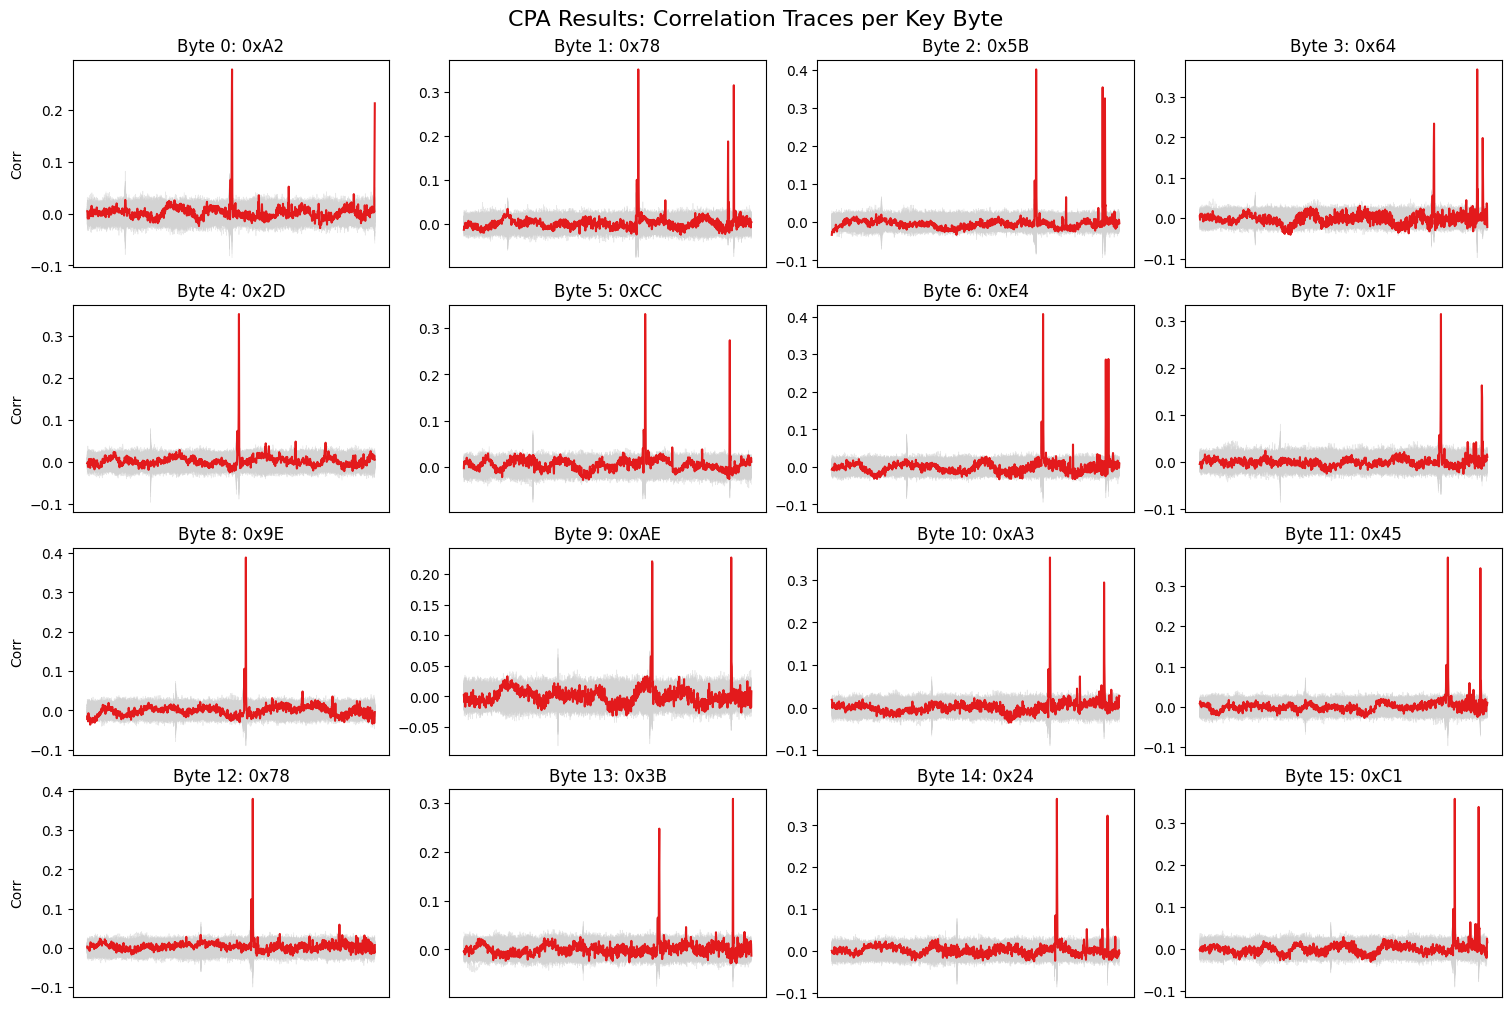

In [17]:
def plot_success(att, recovered_key):
    """Generates a 4x4 grid showing the correlation of the correct key vs wrong guesses."""
    fig, axs = plt.subplots(4, 4, figsize=(15, 10), constrained_layout=True)
    
    for i in range(16):
        ax = axs[i // 4, i % 4]
        
        # Get results: shape (256 guesses, num_samples)
        res_byte = att.results[:, i, :]
        
        # Plot wrong guesses (grey, thin)
        ax.plot(res_byte.T, color='lightgrey', alpha=0.5, linewidth=0.5)
        
        # Plot correct guess (red, bold)
        correct_byte = recovered_key[i]
        ax.plot(res_byte[correct_byte], color='#E31A1C', linewidth=1.5, label='Correct')
        
        ax.set_title(f"Byte {i}: 0x{correct_byte:02X}")
        ax.set_xticks([]) # Hide x-ticks for cleanliness
        if i % 4 == 0: ax.set_ylabel("Corr")

    fig.suptitle('CPA Results: Correlation Traces per Key Byte', fontsize=16)
    plt.show()

plot_success(att, recovered_key)
